In [12]:
import numpy as np

# === 0. Wczytanie danych ===
p = "E:/marcel.furs/Documents/Data_Run_Walk/"
X_train = np.load(p + "dataset_train_multi_fixed_OSTATECZNY.npy")     # (N1,100,55,3)
X_test  = np.load(p + "dataset_test_multi_fixed_OSTATECZNY.npy")      # (N2,100,55,3)
X_anom  = np.load(p + "dataset_anomaly_multi_fixed_OSTATECZNY.npy")   # (N3,100,55,3)

# === 1. Flatten → (N, 16500) ===
def flatten_sequences(X):
    # 55 markerów × 3 osie = 165 cech, na 100 klatek ⇒ 100·165 = 16500
    N, T, M, C = X.shape
    return X.reshape(N, T * M * C)

X_train = flatten_sequences(X_train)
X_test  = flatten_sequences(X_test)
X_anom  = flatten_sequences(X_anom)

# === 2. Z-score per-feature (mean/σ z X_train) ===
mean = X_train.mean(axis=0)        # (16500,)
std  = X_train.std(axis=0)         # (16500,)
std[std < 1e-6] = 1.0              # zabezpieczenie przed ÷0

def zscore(X):
    return (X - mean) / std

X_train = zscore(X_train).astype(np.float32)
X_test  = zscore(X_test).astype(np.float32)
X_anom  = zscore(X_anom).astype(np.float32)

# === 3. Walidacja wymiarów ===
print("Gotowe dane:")
print(" X_train:", X_train.shape, X_train.dtype)
print("  X_test:", X_test .shape, X_test .dtype)
print(" X_anom:", X_anom.shape, X_anom.dtype)


Gotowe dane:
 X_train: (851, 16500) float32
  X_test: (439, 16500) float32
 X_anom: (129, 16500) float32


In [13]:
# Setup

In [14]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"  

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

In [15]:
# Enkoder

In [16]:
input_dim  = X_train.shape[1]          # 16500
latent_dim = 4

encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
#x = layers.Dense( 32, activation="relu")(x)
z = layers.Dense(latent_dim, activation="linear", name="latent")(x)

encoder = keras.Model(encoder_inputs, z, name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 16500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │       4,224,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,257,668 (16.24 MB)

 Trainable params: 4,257,668 (16.24 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Dekoder

In [18]:
latent_inputs = keras.Input(shape=(latent_dim,))
#x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 16500)               │       4,240,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,274,164 (16.30 MB)

 Trainable params: 4,274,164 (16.30 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Class

In [20]:
class AutoEncoder(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs, training=False):
        z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

In [21]:
# Trening

In [22]:
ae = AutoEncoder(encoder, decoder, name="AE_dense")
ae.compile(optimizer='adam', loss='mse')   # tylko MSE!
early = keras.callbacks.EarlyStopping(patience=50,
                                      restore_best_weights=True)

ae.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=50,                        
    batch_size=32,
    shuffle=True,
    callbacks=[early],
    verbose=1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.8036 - val_loss: 0.2668
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.2097 - val_loss: 0.2146
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.2002 - val_loss: 0.1960
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.1841 - val_loss: 0.1834
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.1511 - val_loss: 0.1771
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.1512 - val_loss: 0.1648
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.1302 - val_loss: 0.1827
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.1310 - val_loss: 0.1716
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.1321 - val_loss: 0.1746
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.1270 - val_loss: 0.1646
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.1236 - val_loss: 0.1766
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.1

In [26]:
# 1) Rekonstrukcje
reco_train = ae.predict(X_train, batch_size=32)
reco_test  = ae.predict(X_test,  batch_size=32)
reco_anom  = ae.predict(X_anom,  batch_size=32)

# 2) MSE per-sample
mse_train = np.mean((X_train - reco_train)**2, axis=1)
mse_test  = np.mean((X_test  - reco_test )**2, axis=1)
mse_anom  = np.mean((X_anom  - reco_anom )**2, axis=1)

# 3) Podsumowanie
print(f"MSE train-walk : {mse_train.mean():.4f}")
print(f"MSE test-walk  : {mse_test .mean():.4f}")
print(f"MSE run-anom   : {mse_anom .mean():.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MSE train-walk : 0.1221
MSE test-walk  : 0.1646
MSE run-anom   : 1.8152


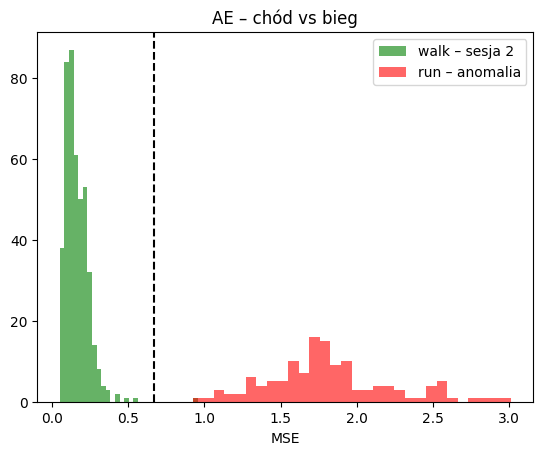

In [46]:

# 4) Histogram z progiem na x-percentylu trainu
import matplotlib.pyplot as plt
alpha = 0.25            # tyle % normalnych wolno odrzucić
thr   = np.percentile(mse_train, 100 - alpha)

plt.hist(mse_test,  bins=30, alpha=.6, label="walk – sesja 2", color="green")
plt.hist(mse_anom, bins=30, alpha=.6, label="run – anomalia",  color="red")
plt.axvline(th,     ls="--", c="k", label=f"")
plt.legend()
plt.xlabel("MSE")
plt.title("AE – chód vs bieg")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


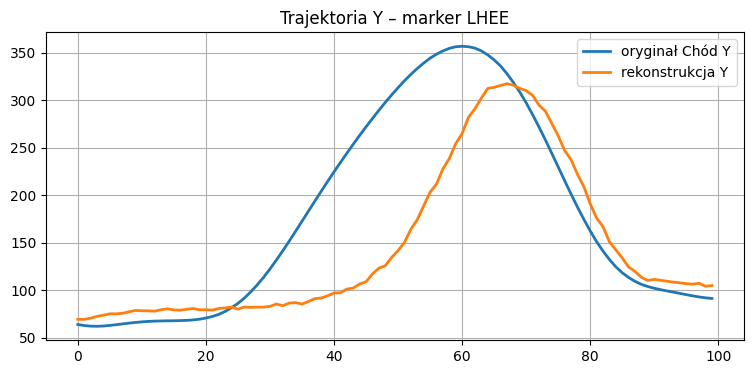

In [181]:
def unscale(x_flat: np.ndarray) -> np.ndarray:
    """
    x_flat: (16500,) – spłaszczona, znormalizowana próbka
    zwraca: (100,55,3) – w oryginalnych jednostkach po odwróceniu z-score
    """
    # 1) odwróć z-score
    flat = x_flat * std + mean   # (16500,)
    # 2) reshape do sekwencji (T=100, markers=55, xyz=3)
    return flat.reshape(100, 55, 3)

idx_best  = np.argmin(mse_anom)              # najlepszy (najmniejszy błąd) bieg
orig_seq  = unscale(X_anom[idx_best])        # X_anom[...] jest już flat (16500,)
reco_seq  = unscale(ae.predict(X_anom[idx_best][None])[0])

# indeks markera LHEE z listy 'wanted'
wanted = [
    "LFHD","RFHD","LBHD","RBHD","GLAB","CLAV","STRN","C7","T2","T10","RBAK",
    "LMAS","RMAS","LASI","LPSI","LTHI","LTHAP","LTHAD","LKNE","LTIB",
    "LTIAP","LTIAD","LANK","LHEE","LTOE","LFMH","LVMH","RASI","RPSI",
    "RTHI","RTHAP","RTHAD","RKNE","RTIB","RTIAP","RTIAD","RANK","RHEE",
    "RTOE","RFMH","RVMH","LSHO","LUPA","LELB","LFRM","LWRA","LWRB","LFIN",
    "RSHO","RUPA","RELB","RFRM","RWRA","RWRB","RFIN"
]
LHEE = wanted.index("LHEE")
plt.figure(figsize=(9,4))
plt.plot(orig_seq[:, LHEE, 2], lw=2, label="oryginał Chód Y")
plt.plot(reco_seq[:, LHEE, 2], lw=2, label="rekonstrukcja Y")
plt.title("Trajektoria Y – marker LHEE")
plt.legend(); plt.grid(); plt.show()


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


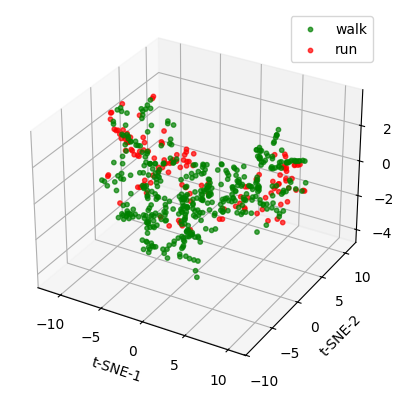

In [27]:
# ------------------------------------------------------------
#  t-SNE 3-D + WIZUALIZACJA
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) latent
Z_walk = encoder.predict(X_test)
Z_run  = encoder.predict(X_anom)

# 2) dane i etykiety
X_lat  = np.concatenate([Z_walk, Z_run], axis=0)
labels = np.array([0]*len(Z_walk) + [1]*len(Z_run))

# 3) t-SNE 3D (domyślne parametry)
X_3d = TSNE(n_components=3, random_state=42).fit_transform(X_lat)

# 4) rysunek
fig = plt.figure()
ax  = fig.add_subplot(projection="3d")
for lab, color, name in zip([0,1], ["green","red"], ["walk","run"]):
    idx = labels == lab
    ax.scatter(X_3d[idx,0], X_3d[idx,1], X_3d[idx,2],
               c=color, s=10, alpha=0.7, label=name)
ax.set_xlabel("t-SNE-1")
ax.set_ylabel("t-SNE-2")
ax.set_zlabel("t-SNE-3")
ax.legend()
plt.show()

# 4) zapis współrzędnych 3-D
#np.save("latent_tsne3d.npy", X_3d)


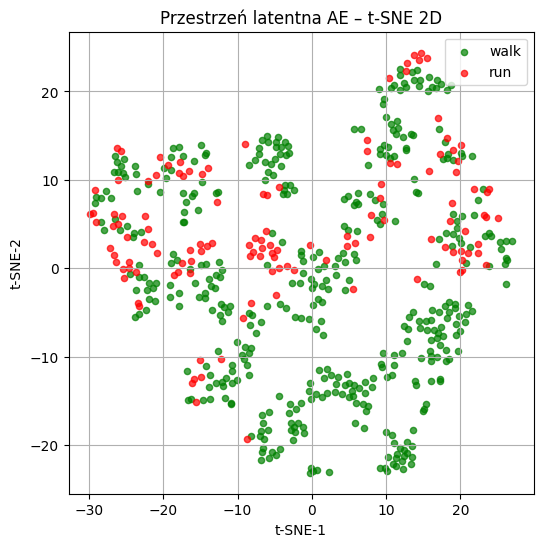

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) Połącz już obliczone latenty
# Z_walk, Z_run masz z poprzedniego kroku
X_lat  = np.concatenate([Z_walk, Z_run], axis=0)
labels = np.array([0]*len(Z_walk) + [1]*len(Z_run))  # 0=walk, 1=run

# 2) t-SNE 2D
X_2d = TSNE(n_components=2, random_state=42).fit_transform(X_lat)

# 3) Scatter 2D
plt.figure(figsize=(6,6))
plt.scatter(
    X_2d[labels==0,0], X_2d[labels==0,1],
    c="green", s=20, alpha=0.7, label="walk"
)
plt.scatter(
    X_2d[labels==1,0], X_2d[labels==1,1],
    c="red",   s=20, alpha=0.7, label="run"
)
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.title("Przestrzeń latentna AE – t-SNE 2D")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# X_test           # (n_walk, 16500) – spłaszczony i z-score'd
# mean, std        # wektory shape=(16500,) do odwrócenia z-score
# wanted           # lista 55 markerów

# 1) Funkcja unscale (odwraca tylko z-score i reshape → (100,55,3))
def unscale_seq(x_flat):
    flat = x_flat * std + mean
    return flat.reshape(100, 55, 3)  # T=100, J=55, xyz=3

# 2) Przykładową sekwencja i jej rekonstrukcja
idx = np.argmin(mse_test)
print("Wybrany idx (najlepsza rekonstrukcja):", idx,
      "MSE =", mse_test[idx])
orig = unscale_seq(X_test[idx])
reco = unscale_seq(ae.predict(X_test[idx:idx+1])[0])

# 3) Wycentruj wokół środka miednicy (LASI/RASI)
LASI, RASI = wanted.index("LASI"), wanted.index("RASI")
pelvis0 = (orig[0, LASI] + orig[0, RASI]) / 2
orig_c = orig - pelvis0
reco_c = reco - pelvis0

# 4) Definicja krawędzi szkieletu
edges = [
    ("LASI","LPSI"), ("LASI","RASI"), ("RASI","RPSI"), ("LPSI","RPSI"),
    ("LASI","LKNE"), ("LKNE","LANK"), ("LANK","LTOE"), ("LANK","LHEE"),
    ("RASI","RKNE"), ("RKNE","RANK"), ("RANK","RTOE"), ("RANK","RHEE"),
    ("CLAV","C7"), ("C7","STRN"),
    ("CLAV","LSHO"), ("LSHO","LELB"), ("LELB","LWRA"), ("LWRA","LFIN"),
    ("CLAV","RSHO"), ("RSHO","RELB"), ("RELB","RWRA"), ("RWRA","RFIN"),
    ("RFHD","LFHD"), ("LBHD","RBHD"), ("RFHD","RBHD"), ("LFHD","LBHD"),
    ("RFHD","GLAB"), ("LFHD","GLAB")
]
edge_idx = [(wanted.index(a), wanted.index(b)) for a,b in edges]

# 5) Przygotuj figurę z dwoma podwykresami 3D
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# wspólne ustawienia osi
xyz_min = np.minimum(orig_c.min((0,1)), reco_c.min((0,1)))
xyz_max = np.maximum(orig_c.max((0,1)), reco_c.max((0,1)))
mid      = (xyz_max + xyz_min) / 2
max_rg   = (xyz_max - xyz_min).max() / 2
for ax in (ax1, ax2):
    ax.set_xlim(mid[0]-max_rg, mid[0]+max_rg)
    ax.set_ylim(mid[1]-max_rg, mid[1]+max_rg)
    ax.set_zlim(mid[2]-max_rg, mid[2]+max_rg)
    ax.view_init(elev=15, azim=-60)

ax1.set_title("Oryginał")
ax2.set_title("Rekonstrukcja")

# linie + punkty
lines1 = [ax1.plot([],[],[],'k-', lw=2)[0] for _ in edge_idx]
pts1   = ax1.scatter([],[],[], c='b', s=10)
lines2 = [ax2.plot([],[],[],'k-', lw=2)[0] for _ in edge_idx]
pts2   = ax2.scatter([],[],[], c='r', s=10)

def init():
    for ln in lines1+lines2:
        ln.set_data([],[]); ln.set_3d_properties([])
    pts1._offsets3d = ([],[],[])
    pts2._offsets3d = ([],[],[])
    return lines1 + [pts1] + lines2 + [pts2]

def update(frame):
    p1 = orig_c[frame]
    p2 = reco_c[frame]
    for ln,(i,j) in zip(lines1, edge_idx):
        ln.set_data(p1[[i,j],0], p1[[i,j],1])
        ln.set_3d_properties(p1[[i,j],2])
    pts1._offsets3d = (p1[:,0], p1[:,1], p1[:,2])
    for ln,(i,j) in zip(lines2, edge_idx):
        ln.set_data(p2[[i,j],0], p2[[i,j],1])
        ln.set_3d_properties(p2[[i,j],2])
    pts2._offsets3d = (p2[:,0], p2[:,1], p2[:,2])
    return lines1 + [pts1] + lines2 + [pts2]

# 6) Generowanie GIF-a
ani = animation.FuncAnimation(
    fig, update, frames=100, init_func=init,
    interval=33, blit=True
)
ani.save("ae_reconstructionMANY.gif", writer="pillow", fps=30)
plt.close(fig)
print(" Zapisano ae_reconstruction.gif")

Wybrany idx (najlepsza rekonstrukcja): 400 MSE = 0.024622332
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
 Zapisano ae_reconstruction.gif
